In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)

In [9]:
import os
print(os.path.exists(os.path.expanduser("~/Downloads/AirPassengers.xlsx")))

True


In [27]:
df = pd.read_excel(os.path.expanduser("~/Downloads/AirPassengers.xlsx"))
df

,Month,Passengers (in thousands)
0,Jan-1949,112
1,Feb-1949,118
2,Mar-1949,132
3,Apr-1949,129
4,May-1949,121
...,...,...
139,Aug-1960,606
140,Sep-1960,508
141,Oct-1960,461
142,Nov-1960,390


In [28]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nFirst rows:")
print(df.head())

Shape: (144, 2)

Columns:
Index(['Month', 'Passengers (in thousands)'], dtype='str')

Data types:
Month                          str
Passengers (in thousands)    int64
dtype: object

First rows:
      Month  Passengers (in thousands)
0  Jan-1949                        112
1  Feb-1949                        118
2  Mar-1949                        132
3  Apr-1949                        129
4  May-1949                        121


In [29]:
df["Month"] = pd.to_datetime(
    df["Month"],
    format="%b-%Y"
)

df = df.sort_values("Month")

df = df.set_index("Month")

df.head()

,Passengers (in thousands)
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [24]:
#check the date range
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Number of observations:", len(df))

Start date: 1949-01-01 00:00:00
End date: 1960-12-01 00:00:00
Number of observations: 144


In [25]:
#check the frequency of the data
print(pd.infer_freq(df.index))

MS


### Create a Complete Monthly Time Index

In [31]:
full_monthly_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="MS"
)

df = df.reindex(full_monthly_index)

df.index.name = "Month"

print(df.shape)
df.head()

(144, 1)


,Passengers (in thousands)
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [33]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 Passengers (in thousands)    0
dtype: int64


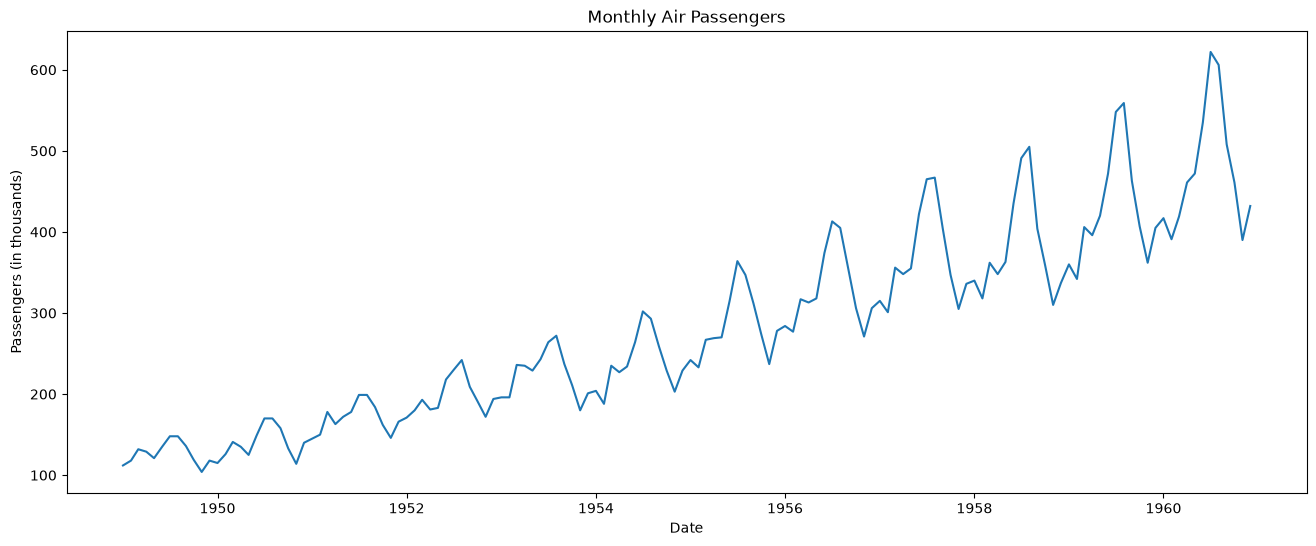

In [35]:
#plot the time series
#Plot the complete time series
plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df["Passengers (in thousands)"]
)

plt.title("Monthly Air Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers (in thousands)")

plt.show()

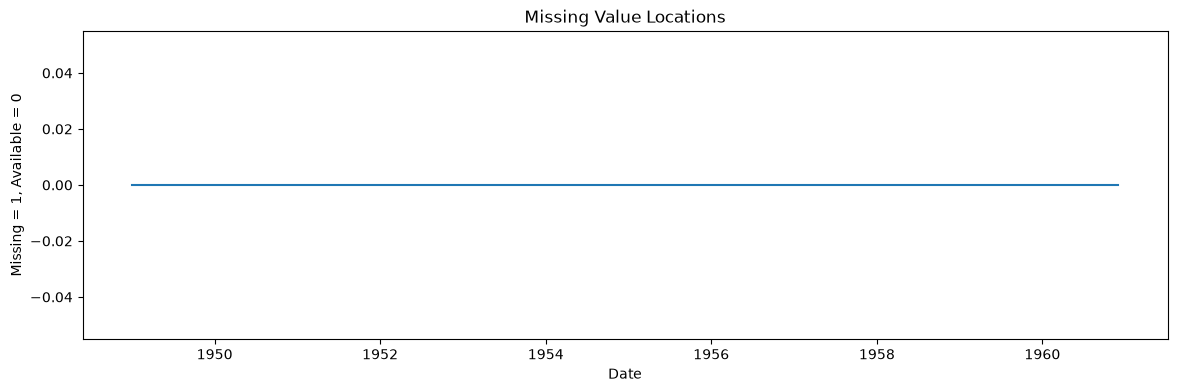

In [37]:
#Plot the missing values
plt.figure(figsize=(14, 4))

plt.plot(
    df.index,
    df["Passengers (in thousands)"].isnull().astype(int)
)

plt.title("Missing Value Locations")
plt.xlabel("Date")
plt.ylabel("Missing = 1, Available = 0")

plt.show()

### Fill Missing Values

In [39]:
df["Passengers (in thousands)"] = df["Passengers (in thousands)"].interpolate(
    method="time"
)

In [41]:
df["Passengers (in thousands)"] = df["Passengers (in thousands)"].bfill()
df["Passengers (in thousands)"] = df["Passengers (in thousands)"].ffill()

In [43]:
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
Passengers (in thousands)    0
dtype: int64


In [45]:
print(df["Passengers (in thousands)"].describe())

count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers (in thousands), dtype: float64


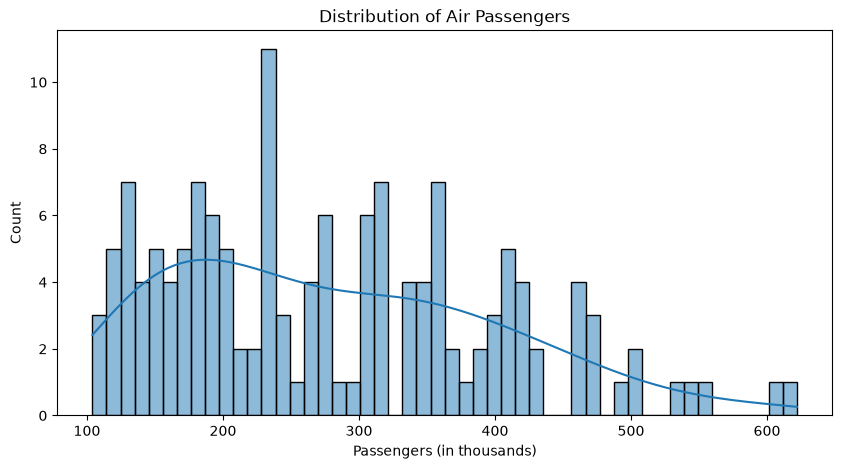

In [47]:
#Plot a histogram of the Passengers column
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Passengers (in thousands)"],
    bins=50,
    kde=True
)

plt.title("Distribution of Air Passengers")
plt.xlabel("Passengers (in thousands)")

plt.show()

In [49]:
print(df["Passengers (in thousands)"].describe())
print("Skewness:", df["Passengers (in thousands)"].skew())
print("Median:", df["Passengers (in thousands)"].median())
print("95th percentile:", df["Passengers (in thousands)"].quantile(0.95))
print("99th percentile:", df["Passengers (in thousands)"].quantile(0.99))

count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers (in thousands), dtype: float64
Skewness: 0.5831604861560892
Median: 265.5
95th percentile: 488.14999999999986
99th percentile: 585.7899999999997


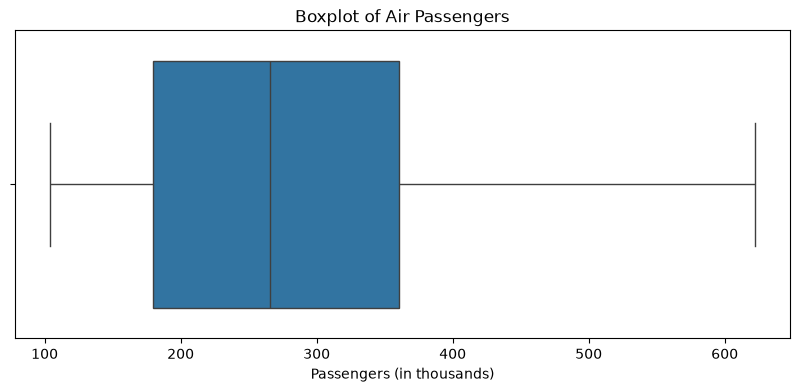

In [51]:
#box plot
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["Passengers (in thousands)"])

plt.title("Boxplot of Air Passengers")

plt.show()

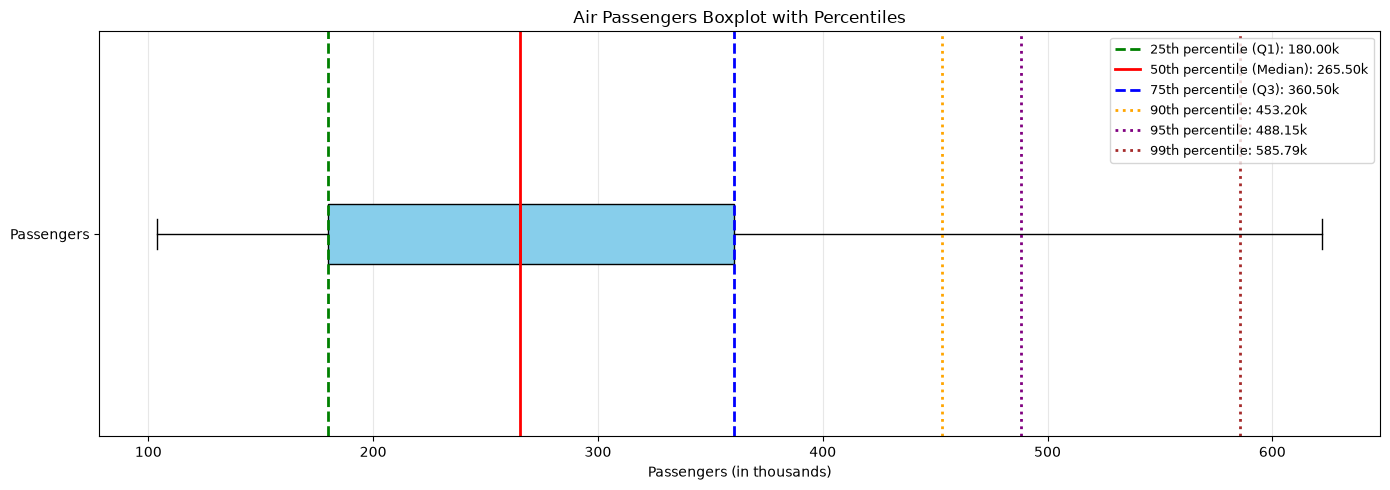

In [52]:
series = df["Passengers (in thousands)"].dropna()

# Calculate percentiles
percentiles = series.quantile([
    0.25, 0.50, 0.75, 0.90, 0.95, 0.99
])

q1 = percentiles[0.25]
median = percentiles[0.50]
q3 = percentiles[0.75]
p90 = percentiles[0.90]
p95 = percentiles[0.95]
p99 = percentiles[0.99]

fig, ax = plt.subplots(figsize=(14, 5))

# Draw the boxplot horizontally
ax.boxplot(
    series,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="black"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=5
    )
)

# Draw and label the quartiles
ax.axvline(q1, color="green", linestyle="--", linewidth=2,
           label=f"25th percentile (Q1): {q1:.2f}k")

ax.axvline(median, color="red", linestyle="-", linewidth=2,
           label=f"50th percentile (Median): {median:.2f}k")

ax.axvline(q3, color="blue", linestyle="--", linewidth=2,
           label=f"75th percentile (Q3): {q3:.2f}k")

# Draw additional percentiles
ax.axvline(p90, color="orange", linestyle=":", linewidth=2,
           label=f"90th percentile: {p90:.2f}k")

ax.axvline(p95, color="purple", linestyle=":", linewidth=2,
           label=f"95th percentile: {p95:.2f}k")

ax.axvline(p99, color="brown", linestyle=":", linewidth=2,
           label=f"99th percentile: {p99:.2f}k")

ax.set_title("Air Passengers Boxplot with Percentiles")
ax.set_xlabel("Passengers (in thousands)")
ax.set_yticks([1])
ax.set_yticklabels(["Passengers"])
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

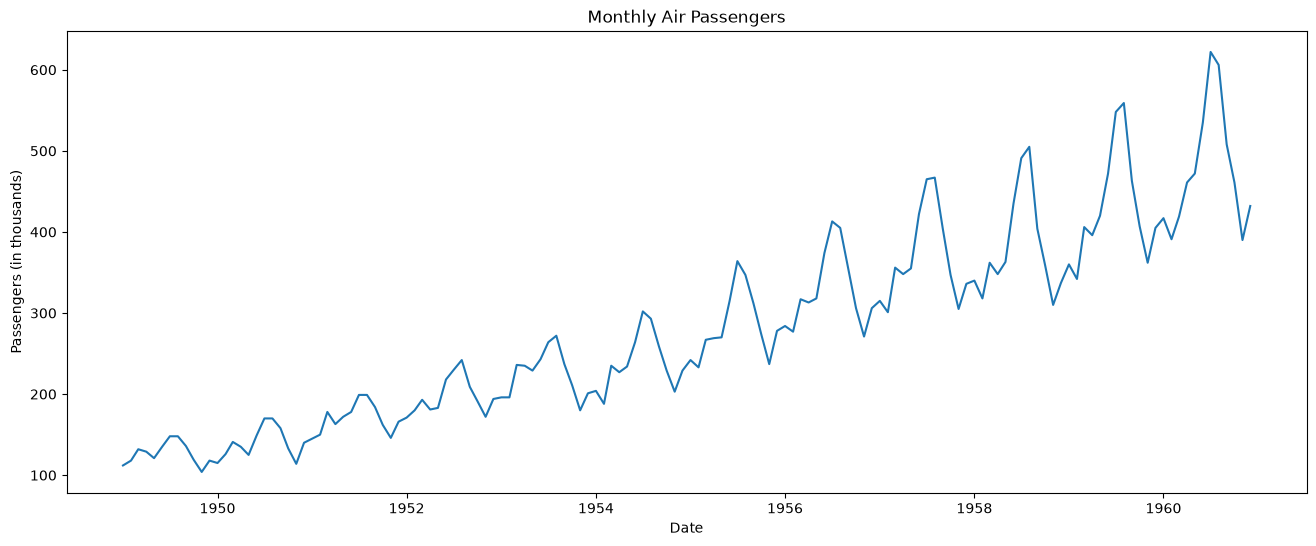

In [53]:
#Plot the complete time series
plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df["Passengers (in thousands)"]
)

plt.title("Monthly Air Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers (in thousands)")

plt.show()

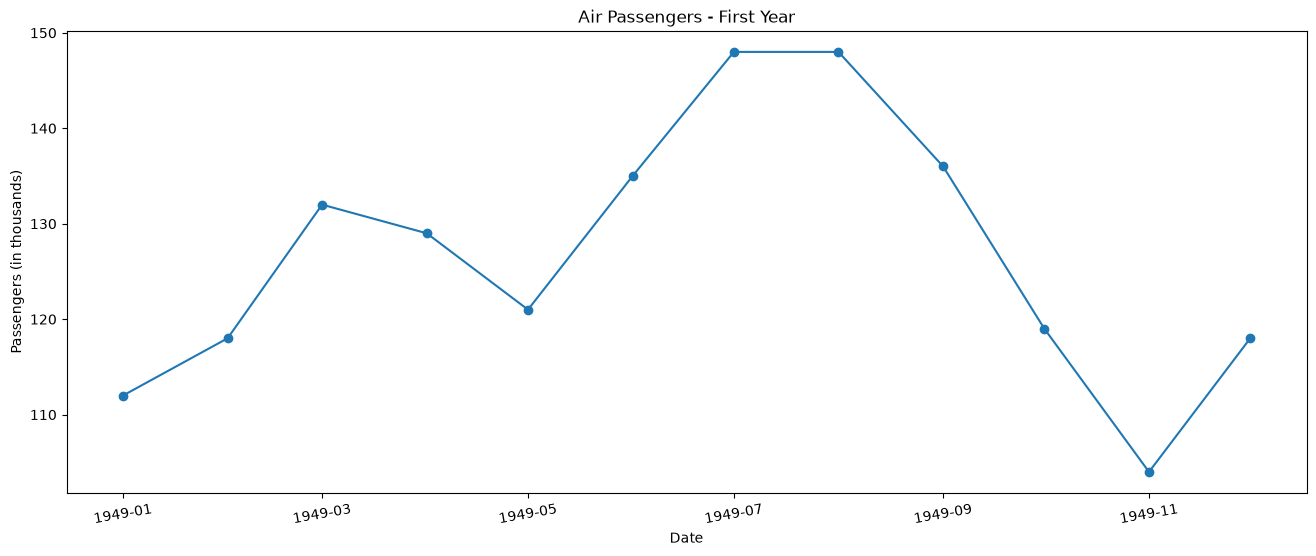

In [54]:
#first year of data
one_year = df.iloc[:12]

plt.figure(figsize=(16, 6))

plt.plot(
    one_year.index,
    one_year["Passengers (in thousands)"],
    marker="o"
)

plt.title("Air Passengers - First Year")
plt.xlabel("Date")
plt.ylabel("Passengers (in thousands)")

plt.xticks(rotation=10)

plt.show()

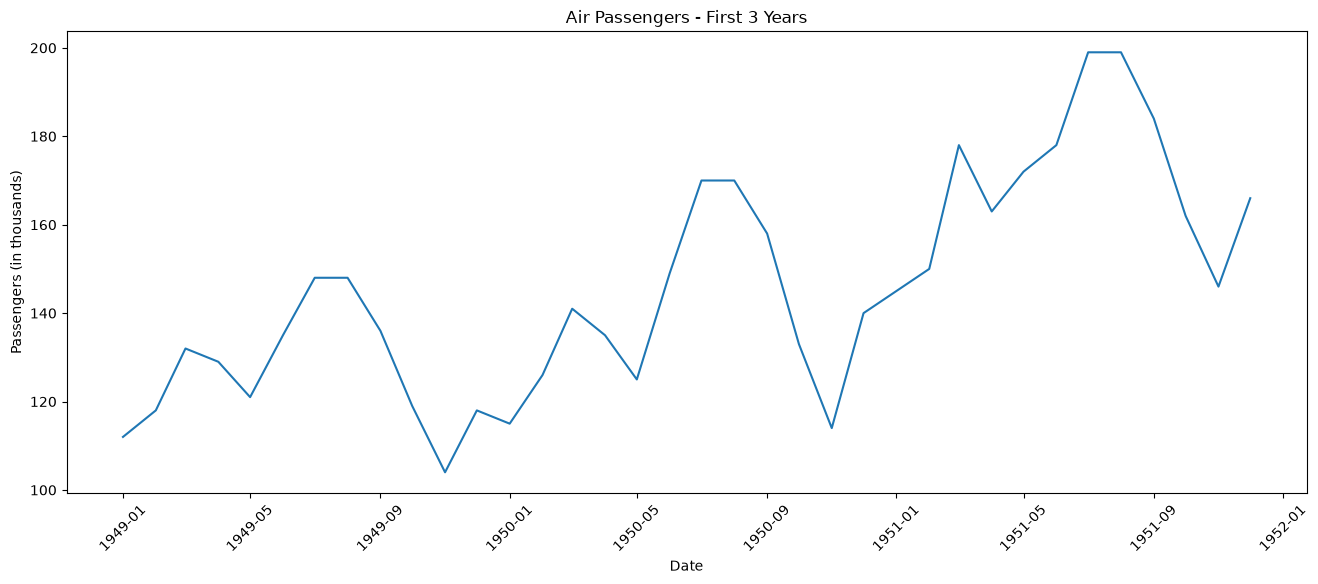

In [56]:
#first 3 years of data
first_3_years = df.iloc[:36]

plt.figure(figsize=(16, 6))

plt.plot(
    first_3_years.index,
    first_3_years["Passengers (in thousands)"]
)

plt.title("Air Passengers - First 3 Years")
plt.xlabel("Date")
plt.ylabel("Passengers (in thousands)")

plt.xticks(rotation=45)

plt.show()

In [58]:
#12-month rolling window
df["rolling_mean_12"] = df["Passengers (in thousands)"].rolling(
    window=12
).mean()

df["rolling_std_12"] = df["Passengers (in thousands)"].rolling(
    window=12
).std()

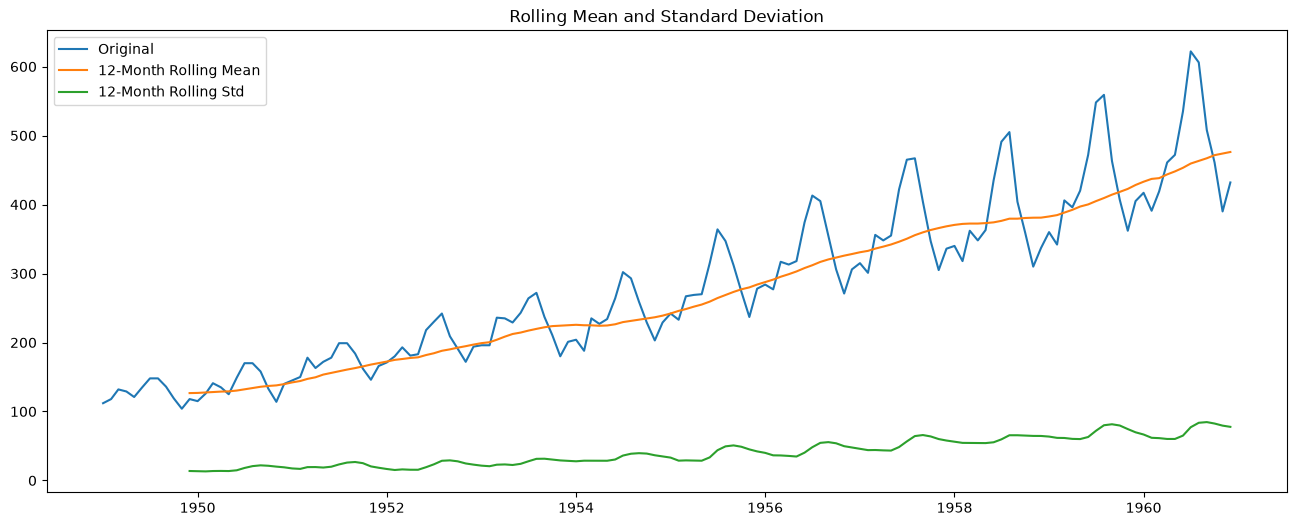

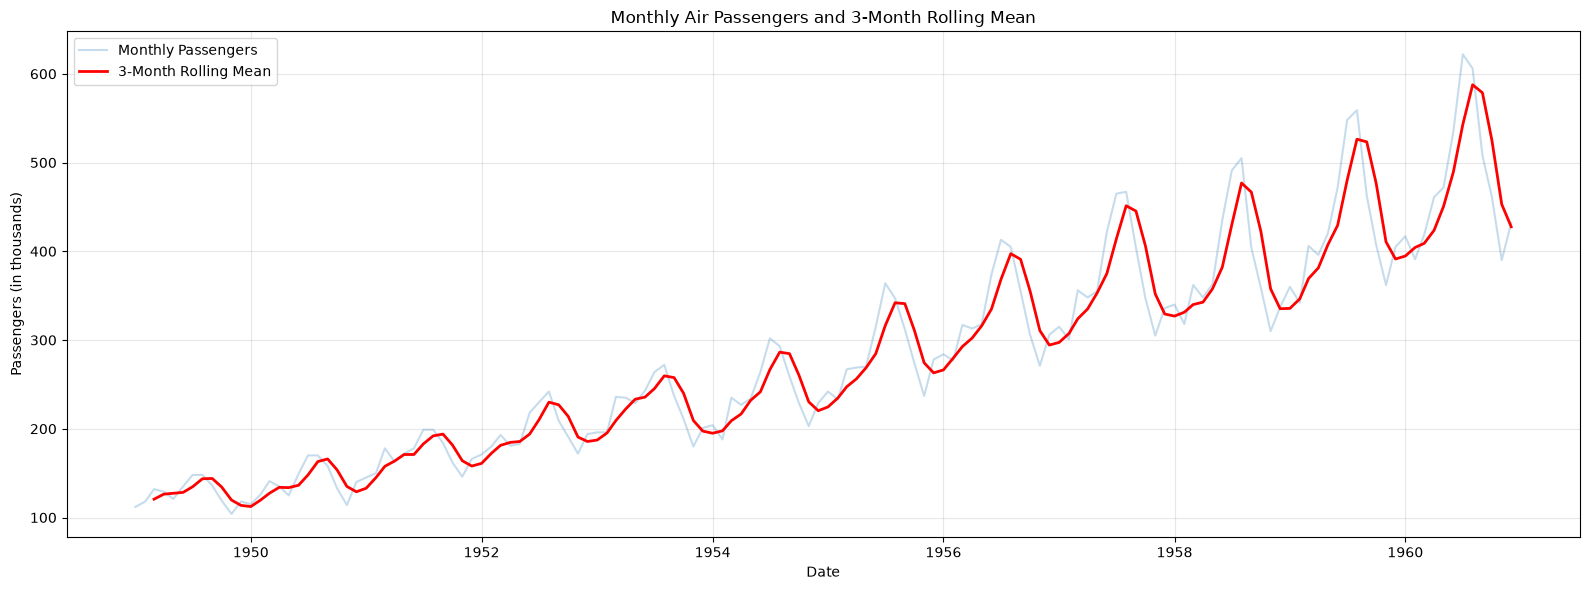

In [60]:
plt.figure(figsize=(16, 6))

plt.plot(
    df["Passengers (in thousands)"],
    label="Original"
)

plt.plot(
    df["rolling_mean_12"],
    label="12-Month Rolling Mean"
)

plt.plot(
    df["rolling_std_12"],
    label="12-Month Rolling Std"
)

plt.title("Rolling Mean and Standard Deviation")
plt.legend()

df["rolling_mean_3m"] = (
    df["Passengers (in thousands)"]
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    df["Passengers (in thousands)"],
    alpha=0.25,
    label="Monthly Passengers"
)

plt.plot(
    df["rolling_mean_3m"],
    color="red",
    linewidth=2,
    label="3-Month Rolling Mean"
)

plt.title("Monthly Air Passengers and 3-Month Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Passengers (in thousands)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.show()

### Trend Analysis


In [64]:
df["trend_12m"] = df["Passengers (in thousands)"].rolling(
    window=12,
    center=True
).mean()

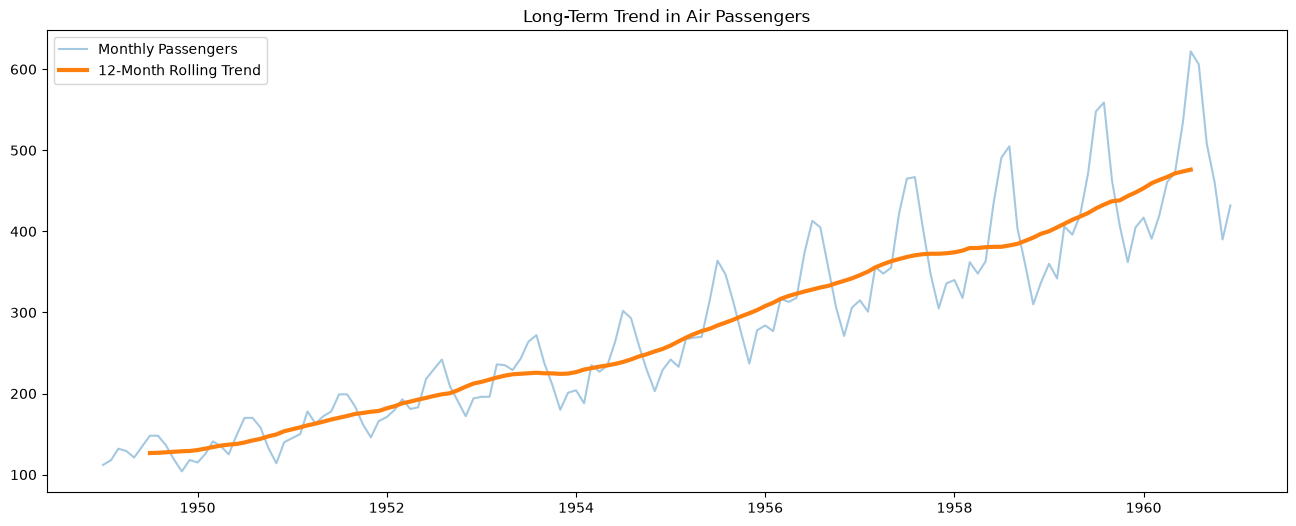

In [66]:
plt.figure(figsize=(16, 6))

plt.plot(
    df["Passengers (in thousands)"],
    alpha=0.4,
    label="Monthly Passengers"
)

plt.plot(
    df["trend_12m"],
    linewidth=3,
    label="12-Month Rolling Trend"
)

plt.title("Long-Term Trend in Air Passengers")
plt.legend()

plt.show()

In [68]:
yearly_mean = df["Passengers (in thousands)"].resample("YE").mean()

yearly_trend = yearly_mean.rolling(
    window=3,
    center=True
).mean()

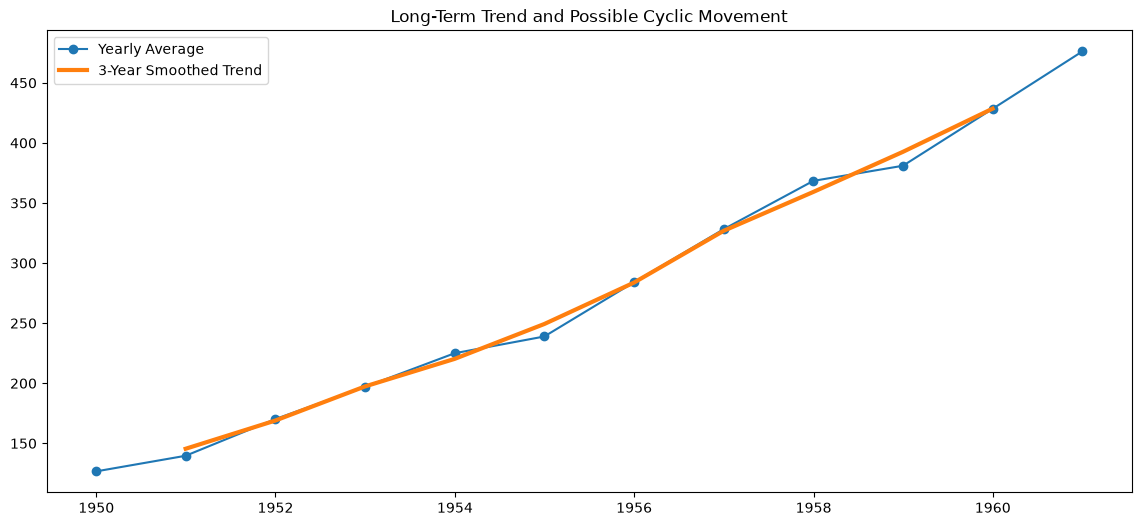

In [70]:
plt.figure(figsize=(14, 6))

plt.plot(
    yearly_mean,
    marker="o",
    label="Yearly Average"
)

plt.plot(
    yearly_trend,
    linewidth=3,
    label="3-Year Smoothed Trend"
)

plt.title("Long-Term Trend and Possible Cyclic Movement")
plt.legend()

plt.show()

In [71]:
series = df["Passengers (in thousands)"].dropna()

train_size = int(len(series) * 0.80)

train = series.iloc[:train_size]
test = series.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 115
Test size: 29


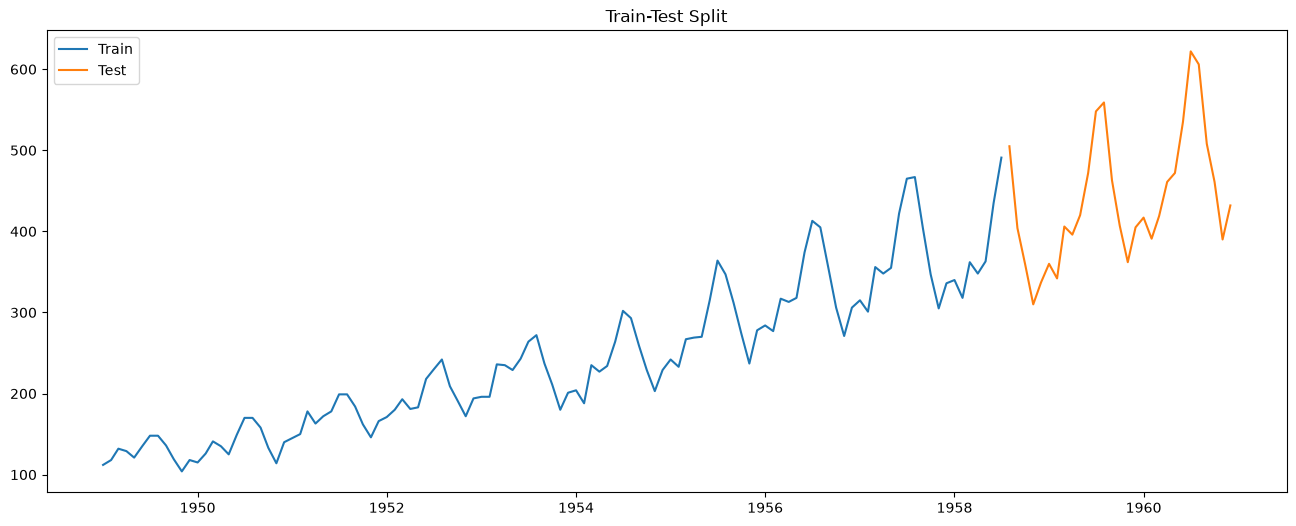

In [73]:
plt.figure(figsize=(16, 6))

plt.plot(
    train,
    label="Train"
)

plt.plot(
    test,
    label="Test"
)

plt.title("Train-Test Split")
plt.legend()

plt.show()

In [74]:
def evaluate_forecast(actual, predicted, model_name):

    mae = mean_absolute_error(actual, predicted)

    mse = mean_squared_error(actual, predicted)

    rmse = np.sqrt(mse)

    print(f"===== {model_name} =====")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    }

In [76]:
p = 12

ar_model = ARIMA(
    train,
    order=(p, 0, 0)
)

ar_results = ar_model.fit()

ar_forecast = ar_results.forecast(
    steps=len(test)
)

ar_metrics = evaluate_forecast(
    test,
    ar_forecast,
    f"AR({p})"
)

===== AR(12) =====
MAE  : 61.6149
MSE  : 6206.8974
RMSE : 78.7839


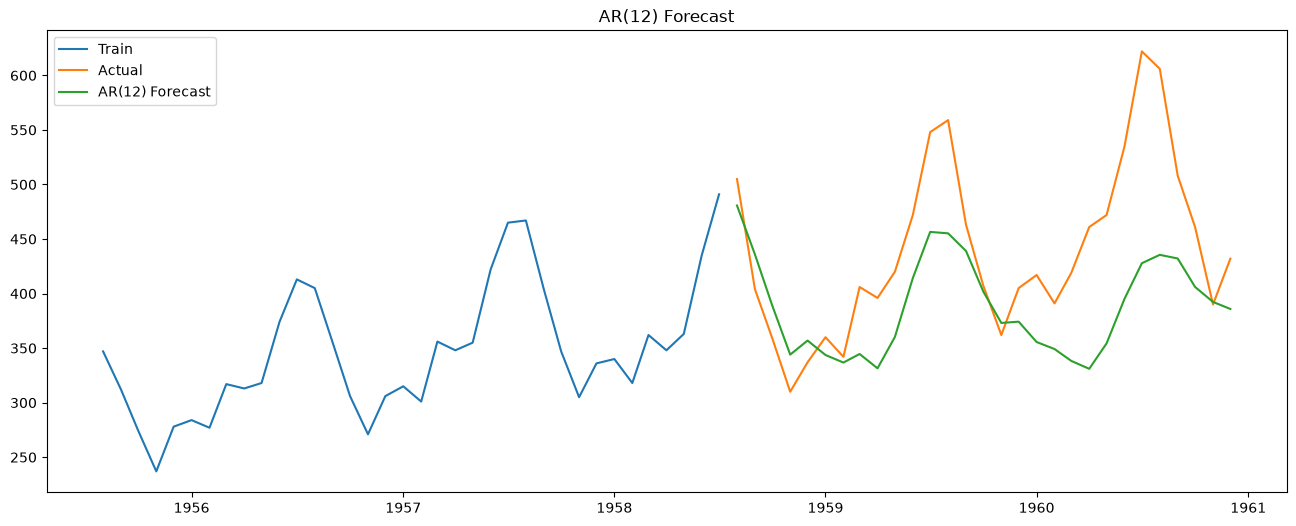

In [78]:
plt.figure(figsize=(16, 6))

plt.plot(
    train.tail(36),
    label="Train"
)

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    ar_forecast,
    label=f"AR({p}) Forecast"
)

plt.title(f"AR({p}) Forecast")

plt.legend()

plt.show()

In [80]:
q = 4

ma_model = ARIMA(
    train,
    order=(0, 0, q)
)

ma_results = ma_model.fit()

ma_forecast = ma_results.forecast(
    steps=len(test)
)

ma_metrics = evaluate_forecast(
    test,
    ma_forecast,
    f"MA({q})"
)

===== MA(4) =====
MAE  : 183.5128
MSE  : 42414.0135
RMSE : 205.9466


### ARMA Model

In [82]:
p = 12
q = 4

arma_model = ARIMA(
    train,
    order=(p, 0, q)
)

arma_results = arma_model.fit()

arma_forecast = arma_results.forecast(
    steps=len(test)
)

arma_metrics = evaluate_forecast(
    test,
    arma_forecast,
    f"ARMA({p},{q})"
)

===== ARMA(12,4) =====
MAE  : 58.9124
MSE  : 5451.7169
RMSE : 73.8357


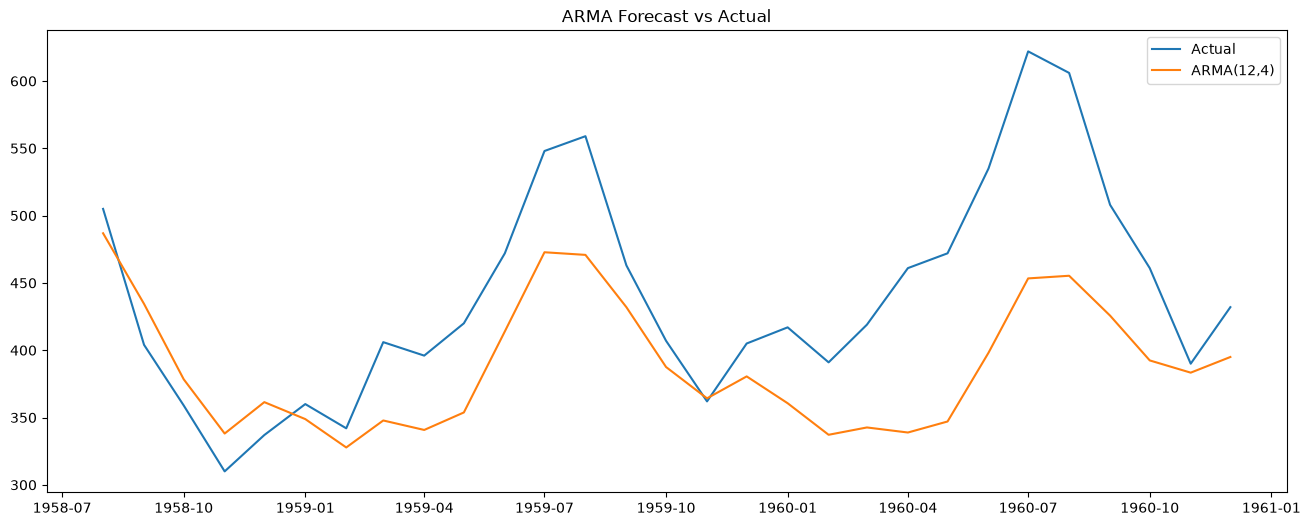

In [84]:
plt.figure(figsize=(16, 6))

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    arma_forecast,
    label=f"ARMA({p},{q})"
)

plt.title("ARMA Forecast vs Actual")

plt.legend()

plt.show()

In [89]:
ar_results_list = []

for p in range(1, 13):

    try:

        model = ARIMA(
            train,
            order=(p, 0, 0)
        )

        result = model.fit()

        forecast = result.forecast(
            steps=len(test)
        )

        metrics = evaluate_forecast(
            test,
            forecast,
            f"AR({p})"
        )

        metrics["AIC"] = result.aic
        metrics["BIC"] = result.bic

        ar_results_list.append(metrics)

    except Exception as e:

        print(f"AR({p}) failed:", e)

===== AR(1) =====
MAE  : 75.7810
MSE  : 9177.1294
RMSE : 95.7973
===== AR(2) =====
MAE  : 104.7540
MSE  : 16424.8821
RMSE : 128.1596
===== AR(3) =====
MAE  : 89.9301
MSE  : 12697.3091
RMSE : 112.6823
===== AR(4) =====
MAE  : 84.6926
MSE  : 11488.1394
RMSE : 107.1827
===== AR(5) =====
MAE  : 70.5880
MSE  : 8446.6713
RMSE : 91.9058
===== AR(6) =====
MAE  : 71.3376
MSE  : 8420.5767
RMSE : 91.7637
===== AR(7) =====
MAE  : 69.8389
MSE  : 8357.2694
RMSE : 91.4181
===== AR(8) =====
MAE  : 64.0358
MSE  : 7635.2919
RMSE : 87.3802
===== AR(9) =====
MAE  : 63.8024
MSE  : 6822.8266
RMSE : 82.6004
===== AR(10) =====
MAE  : 63.6776
MSE  : 6689.4426
RMSE : 81.7890
===== AR(11) =====
MAE  : 62.6656
MSE  : 6493.8532
RMSE : 80.5844
===== AR(12) =====
MAE  : 61.6149
MSE  : 6206.8974
RMSE : 78.7839


In [91]:
# results
ar_comparison = pd.DataFrame(ar_results_list)

ar_comparison = ar_comparison.sort_values(
    "RMSE"
)

print(ar_comparison)

     Model         MAE           MSE        RMSE          AIC          BIC
11  AR(12)   61.614908   6206.897383   78.783865  1015.929185  1054.358235
10  AR(11)   62.665624   6493.853217   80.584448  1018.560459  1054.244576
9   AR(10)   63.677592   6689.442633   81.789013  1052.290186  1085.229372
8    AR(9)   63.802433   6822.826633   82.600403  1052.906706  1083.100960
7    AR(8)   64.035771   7635.291924   87.380157  1076.473015  1103.922337
6    AR(7)   69.838884   8357.269353   91.418102  1078.458543  1103.162932
5    AR(6)   71.337574   8420.576714   91.763700  1077.178744  1099.138201
4    AR(5)   70.587976   8446.671268   91.905774  1075.898695  1095.113219
0    AR(1)   75.780989   9177.129448   95.797335  1092.214250  1100.449046
3    AR(4)   84.692553  11488.139393  107.182738  1083.048384  1099.517977
2    AR(3)   89.930135  12697.309090  112.682337  1081.138672  1094.863333
1    AR(2)  104.753969  16424.882109  128.159596  1083.133770  1094.113499


In [93]:
ma_results_list = []

for q in range(1, 13):

    try:
        model = ARIMA(
            train,
            order=(0, 0, q)
        )

        result = model.fit()

        forecast = result.forecast(
            steps=len(test)
        )

        metrics = evaluate_forecast(
            test,
            forecast,
            f"MA({q})"
        )

        metrics["AIC"] = result.aic
        metrics["BIC"] = result.bic

        ma_results_list.append(metrics)

    except Exception as e:
        print(f"MA({q}) failed:", e)

===== MA(1) =====
MAE  : 195.3139
MSE  : 44249.2831
RMSE : 210.3551
===== MA(2) =====
MAE  : 190.2998
MSE  : 42950.6665
RMSE : 207.2454
===== MA(3) =====
MAE  : 182.0907
MSE  : 41629.9198
RMSE : 204.0341
===== MA(4) =====
MAE  : 183.5128
MSE  : 42414.0135
RMSE : 205.9466
===== MA(5) =====
MAE  : 182.7464
MSE  : 42456.1236
RMSE : 206.0488
===== MA(6) =====
MAE  : 178.4945
MSE  : 41700.0652
RMSE : 204.2059
===== MA(7) =====
MAE  : 177.6941
MSE  : 41586.3536
RMSE : 203.9273
===== MA(8) =====
MAE  : 184.9024
MSE  : 42924.4121
RMSE : 207.1821
===== MA(9) =====
MAE  : 178.8859
MSE  : 41622.3527
RMSE : 204.0156
===== MA(10) =====
MAE  : 176.7723
MSE  : 41087.2935
RMSE : 202.7000
===== MA(11) =====
MAE  : 177.4516
MSE  : 41235.8237
RMSE : 203.0661
===== MA(12) =====
MAE  : 175.8355
MSE  : 41070.7445
RMSE : 202.6592


In [95]:
# create the comparision table
ma_comparison = pd.DataFrame(ma_results_list)

ma_comparison = ma_comparison.sort_values("RMSE")

print(ma_comparison)

     Model         MAE           MSE        RMSE          AIC          BIC
11  MA(12)  175.835489  41070.744546  202.659183  1082.234022  1120.663072
9   MA(10)  176.772329  41087.293486  202.700009  1036.960525  1069.899711
10  MA(11)  177.451558  41235.823653  203.066057  1038.277040  1073.961158
6    MA(7)  177.694055  41586.353611  203.927324  1068.237073  1092.941462
8    MA(9)  178.885860  41622.352735  204.015570  1118.505202  1148.699456
2    MA(3)  182.090689  41629.919762  204.034114  1113.462064  1127.186725
5    MA(6)  178.494459  41700.065196  204.205938  1106.974627  1128.934084
3    MA(4)  183.512787  42414.013473  205.946628  1106.327011  1122.796604
4    MA(5)  182.746426  42456.123587  206.048838  1085.576207  1104.790732
7    MA(8)  184.902392  42924.412066  207.182075  1088.028733  1115.478054
1    MA(2)  190.299769  42950.666524  207.245426  1178.064577  1189.044306
0    MA(1)  195.313880  44249.283086  210.355136  1232.916728  1241.151525


In [96]:
# Best MA model:
best_ma = ma_comparison.iloc[0]

print("Best MA Model:")
print(best_ma)

Best MA Model:
Model          MA(12)
MAE        175.835489
MSE      41070.744546
RMSE       202.659183
AIC       1082.234022
BIC       1120.663072
Name: 11, dtype: object


In [99]:
arma_results_list = []

for p in range(1, 6):

    for q in range(1, 6):

        try:

            print(f"Testing ARMA({p},{q})")

            model = ARIMA(
                train,
                order=(p, 0, q)
            )

            result = model.fit()

            forecast = result.forecast(
                steps=len(test)
            )

            metrics = evaluate_forecast(
                test,
                forecast,
                f"ARMA({p},{q})"
            )

            metrics["p"] = p
            metrics["q"] = q
            metrics["AIC"] = result.aic
            metrics["BIC"] = result.bic

            arma_results_list.append(metrics)

        except Exception as e:

            print(f"ARMA({p},{q}) failed:", e)

Testing ARMA(1,1)
===== ARMA(1,1) =====
MAE  : 105.0511
MSE  : 16633.0893
RMSE : 128.9693
Testing ARMA(1,2)
===== ARMA(1,2) =====
MAE  : 81.2098
MSE  : 10737.0134
RMSE : 103.6196
Testing ARMA(1,3)
===== ARMA(1,3) =====
MAE  : 101.3905
MSE  : 15532.8065
RMSE : 124.6307
Testing ARMA(1,4)
===== ARMA(1,4) =====
MAE  : 65.4420
MSE  : 7790.0786
RMSE : 88.2614
Testing ARMA(1,5)
===== ARMA(1,5) =====
MAE  : 158.3725
MSE  : 33904.1761
RMSE : 184.1309
Testing ARMA(2,1)
===== ARMA(2,1) =====
MAE  : 88.5675
MSE  : 12336.6778
RMSE : 111.0706
Testing ARMA(2,2)
===== ARMA(2,2) =====
MAE  : 92.2555
MSE  : 13202.6821
RMSE : 114.9029
Testing ARMA(2,3)
===== ARMA(2,3) =====
MAE  : 67.6222
MSE  : 8207.8870
RMSE : 90.5974
Testing ARMA(2,4)
===== ARMA(2,4) =====
MAE  : 65.9168
MSE  : 7916.4550
RMSE : 88.9745
Testing ARMA(2,5)
===== ARMA(2,5) =====
MAE  : 182.0756
MSE  : 42251.9896
RMSE : 205.5529
Testing ARMA(3,1)
===== ARMA(3,1) =====
MAE  : 99.5511
MSE  : 15079.8513
RMSE : 122.8000
Testing ARMA(3,2)
=====

In [102]:

#result table
arma_comparison = pd.DataFrame(arma_results_list)

arma_comparison = arma_comparison.sort_values("RMSE")

arma_comparison.head(10)

,Model,MAE,MSE,RMSE,p,q,AIC,BIC
17,"ARMA(4,3)",61.254624,6156.023801,78.460333,4,3,1045.314728,1070.019117
19,"ARMA(4,5)",64.830820,6284.090143,79.272253,4,5,1044.050226,1074.244479
22,"ARMA(5,3)",58.367630,6655.715460,81.582568,5,3,1056.178881,1083.628202
14,"ARMA(3,5)",63.381867,7292.506621,85.396175,3,5,1059.103999,1086.553320
3,"ARMA(1,4)",65.441968,7790.078641,88.261422,1,4,1066.615890,1085.830414
8,"ARMA(2,4)",65.916778,7916.455004,88.974463,2,4,1071.354156,1093.313613
13,"ARMA(3,4)",66.701308,8064.077972,89.800211,3,4,1060.893209,1085.597598
7,"ARMA(2,3)",67.622232,8207.887037,90.597390,2,3,1075.434687,1094.649212
12,"ARMA(3,3)",68.070125,8241.228490,90.781212,3,3,1073.081018,1095.040475
18,"ARMA(4,4)",71.311557,8861.818377,94.137232,4,4,1057.715931,1085.165253


In [104]:
#best arma model
best_arma = arma_comparison.iloc[0]

print("Best ARMA Model:")
print(best_arma)

Best ARMA Model:
Model      ARMA(4,3)
MAE        61.254624
MSE      6156.023801
RMSE       78.460333
p                  4
q                  3
AIC      1045.314728
BIC      1070.019117
Name: 17, dtype: object


In [106]:
#get the best AR model
best_ar = ar_comparison.iloc[0]

print("Best AR Model:")
print(best_ar)

Best AR Model:
Model         AR(12)
MAE        61.614908
MSE      6206.897383
RMSE       78.783865
AIC      1015.929185
BIC      1054.358235
Name: 11, dtype: object


In [108]:
#get the best MA model
best_ma = ma_comparison.iloc[0]

print("\nBest MA Model:")
print(best_ma)


Best MA Model:
Model          MA(12)
MAE        175.835489
MSE      41070.744546
RMSE       202.659183
AIC       1082.234022
BIC       1120.663072
Name: 11, dtype: object


In [110]:
# get the best arma model
best_arma = arma_comparison.iloc[0]

print("\nBest ARMA Model:")
print(best_arma)


Best ARMA Model:
Model      ARMA(4,3)
MAE        61.254624
MSE      6156.023801
RMSE       78.460333
p                  4
q                  3
AIC      1045.314728
BIC      1070.019117
Name: 17, dtype: object


In [111]:
#combine them
best_models = pd.DataFrame([
    best_ar,
    best_ma,
    best_arma
])

best_models = best_models.sort_values("RMSE")

best_models

,Model,MAE,MSE,RMSE,AIC,BIC,p,q
17,"ARMA(4,3)",61.254624,6156.023801,78.460333,1045.314728,1070.019117,4.0,3.0
11,AR(12),61.614908,6206.897383,78.783865,1015.929185,1054.358235,NaN,NaN
11,MA(12),175.835489,41070.744546,202.659183,1082.234022,1120.663072,NaN,NaN
